In [ ]:
from _architecture import Base

import numpy as np
import matplotlib.pyplot as plt

In [2]:
X,Y = np.random.randint(low=1,high=30,size=(2,30))

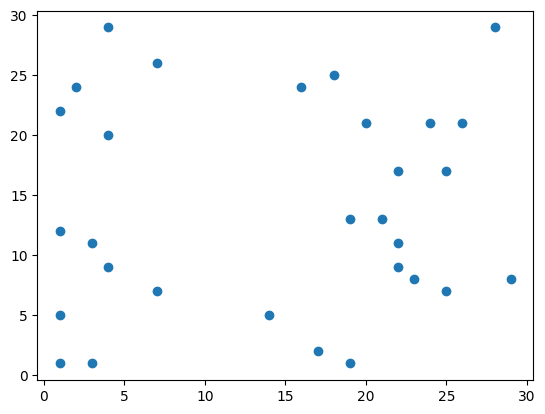

In [3]:
plt.scatter(X,Y)
plt.show()

In [ ]:
class simple_linear_regression(Base):


    def _compute_loss(self,y_true, y_pred):

        return np.mean(np.square(y_pred - y_true))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._weights = np.zeros(n_features)
        self._bias = 0.0 
        prev_loss = np.inf
        _wait = 0
        tol = 0
        
        for itr in range(self.max_iterations):
            _y = np.dot(X, self._weights) + self._bias
            error = _y - y
            
            w_grad = (2 / n_samples) * np.dot(X.T, error)            
            b_grad = (2 / n_samples) * np.sum(error)

            _loss = self._compute_loss(y, _y)

            self._weights -= (self.lr * w_grad)
            self._bias -= (self.lr * b_grad)

            if abs(prev_loss - _loss) < tol:
                _wait += 1
            else:
                _wait = 0 

            if _wait >= self.patience:
                if self._verbose: print(f"Converged at iteration {itr}")
                break

            if self._verbose and itr % 1000 == 0:
                print(f'[{itr}/{self.max_iterations}] loss : {_loss:.6f}')

            prev_loss = _loss
                
        self._is_fitted = True
        
        
    def predict(self,X):
        
        return X*self._weights + self._bias
    
    def score(self, y_true, y_pred):
        return self._compute_loss(y_true,y_pred)
    

    

In [5]:
lr_reg = simple_linear_regression(max_iterations = int(5e5),verbose=True, lr = 1e-4)

X_ = np.expand_dims(X,1)
lr_reg.fit(X_,Y)

[0/500000] loss : 269.633333
[1000/500000] loss : 120.435593
[2000/500000] loss : 114.969210
[3000/500000] loss : 110.147688
[4000/500000] loss : 105.894953
[5000/500000] loss : 102.143905
[6000/500000] loss : 98.835363
[7000/500000] loss : 95.917124
[8000/500000] loss : 93.343145
[9000/500000] loss : 91.072815
[10000/500000] loss : 89.070311
[11000/500000] loss : 87.304039
[12000/500000] loss : 85.746132
[13000/500000] loss : 84.372008
[14000/500000] loss : 83.159988
[15000/500000] loss : 82.090948
[16000/500000] loss : 81.148020
[17000/500000] loss : 80.316328
[18000/500000] loss : 79.582750
[19000/500000] loss : 78.935711
[20000/500000] loss : 78.365001
[21000/500000] loss : 77.861618
[22000/500000] loss : 77.417618
[23000/500000] loss : 77.025995
[24000/500000] loss : 76.680572
[25000/500000] loss : 76.375898
[26000/500000] loss : 76.107166
[27000/500000] loss : 75.870135
[28000/500000] loss : 75.661067
[29000/500000] loss : 75.476662
[30000/500000] loss : 75.314011
[31000/500000] 

In [6]:
y_pred = lr_reg.predict(X_)
y_pred

array([[14.93846959],
       [14.30160845],
       [13.02788617],
       [13.24017322],
       [14.79694489],
       [13.24017322],
       [14.44313315],
       [14.2308461 ],
       [13.24017322],
       [13.16941087],
       [14.0893214 ],
       [13.02788617],
       [14.6554202 ],
       [14.30160845],
       [14.5138955 ],
       [13.45246026],
       [14.5138955 ],
       [13.16941087],
       [14.58465785],
       [13.94779671],
       [13.09864852],
       [13.02788617],
       [13.45246026],
       [14.5138955 ],
       [14.3723708 ],
       [14.72618254],
       [14.72618254],
       [13.02788617],
       [15.00923194],
       [14.16008375]])

In [7]:
print('RMSE : ',lr_reg.score(Y,y_pred))

RMSE :  75.03321605702914


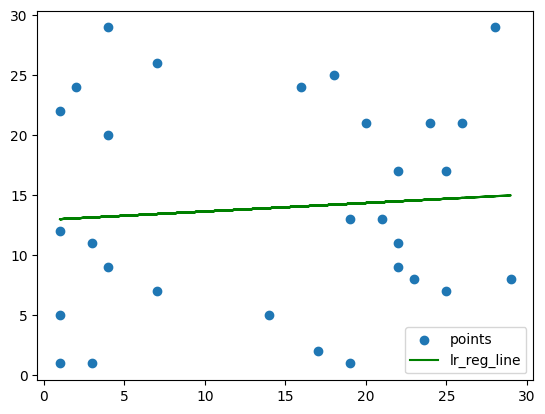

In [8]:
plt.scatter(X,Y,label='points')
plt.plot(X,y_pred,label='lr_reg_line',color="green")
plt.legend()
plt.show()

### Lets check our custom model performance against real model


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


lr_reg_2 = LinearRegression()
lr_reg_2.fit(X_,Y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred_2 = lr_reg_2.predict(X_)
print(y_pred_2)
print('RMSE : ',mean_squared_error(Y,y_pred_2))

[14.93846959 14.30160845 13.02788617 13.24017322 14.79694489 13.24017322
 14.44313315 14.2308461  13.24017322 13.16941087 14.0893214  13.02788617
 14.6554202  14.30160845 14.5138955  13.45246026 14.5138955  13.16941087
 14.58465785 13.94779671 13.09864852 13.02788617 13.45246026 14.5138955
 14.3723708  14.72618254 14.72618254 13.02788617 15.00923194 14.16008375]
RMSE :  74.09789505409091


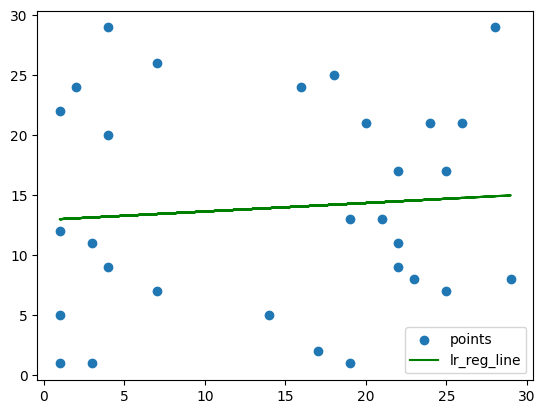

In [11]:
plt.scatter(X,Y,label='points')
plt.plot(X,y_pred_2,label='lr_reg_line',color="green")
plt.legend()
plt.show()

In [12]:
np.sum(y_pred_2 - y_pred.squeeze())

np.float64(1.3318945946139138e-10)

In [13]:
## sklearn linear regression is way faster and accurate !!

In [ ]:
class OLSLinearRegression(Base):

    def __init__(self):
        self._is_fitted = False

    def fit(self, X, y):
        n_samples = X.shape[0]
        _X = np.c_[np.ones(n_samples), X]
        # w  = (X^T * X)^-1 * X^T * y
        weights_full = np.linalg.inv(_X.T @ _X) @ _X.T @ y
        
        self.bias_ = weights_full[0]
        self.weights_ = weights_full[1:]
        self._is_fitted = True

    def _compute_loss(self,y_true, y_pred):
        return np.mean(np.square(y_true-y_pred))

    def score(self, y_true, y_pred):
        return self._compute_loss(y_true,y_pred)        

    def predict(self, X):
        return np.dot(X, self.weights_) + self.bias_


In [15]:
lr_os_reg = OLSLinearRegression()
lr_os_reg.fit(X_,Y)


In [16]:
y_pred_3 = lr_os_reg.predict(X_)
y_pred_3

array([14.93846959, 14.30160845, 13.02788617, 13.24017322, 14.79694489,
       13.24017322, 14.44313315, 14.2308461 , 13.24017322, 13.16941087,
       14.0893214 , 13.02788617, 14.6554202 , 14.30160845, 14.5138955 ,
       13.45246026, 14.5138955 , 13.16941087, 14.58465785, 13.94779671,
       13.09864852, 13.02788617, 13.45246026, 14.5138955 , 14.3723708 ,
       14.72618254, 14.72618254, 13.02788617, 15.00923194, 14.16008375])

In [17]:
print('RMSE : ',lr_os_reg.score(Y,y_pred_3))

RMSE :  74.09789505409094


In [18]:
# now we're equal !!
# sklearn uses OLS based approach to directly reach to the bottom of optimization space without going through any iterative process.

# It uses LAPACK dgelsd (via scipy.linalg.lstsq). This is a solver based on Singular Value Decomposition (SVD). 